#### Imports

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from pathlib import Path
import tensorflow as tf
import numpy as np


#### Verifying Folder Path

In [3]:
dataPath = Path("..\\Data")

if dataPath.is_dir():
    print("This is a folder.")
else:
    print("Not Found")

This is a folder.


#### Identifying Each Dataset

In [4]:
datasetOne, datasetTwo = [x for x in dataPath.iterdir()]
print(datasetOne)
print(datasetTwo)

..\Data\Flowers Recognition Data (1)
..\Data\Flowers Recognition Data (2)


#### Loading Dataset 1
The following snippet of code goes through each of the group folders (*daisy*, *dandelion*, etc.) and then adds each of the images found in those folders to the list *imagesOne*. As the image path is being added to *imagesOne*, the label (group folder name) is being added to *labelsOne*. The idea is that the indices of *imagesOne* and *labelsOne* line up, relating the image to the image path.

In [5]:
imagesOne = []
labelsOne = []

# Goes through each group's folder
for class_dir in datasetOne.iterdir():
    if class_dir.is_dir():
        for img_file in class_dir.iterdir():
            # Adds image path to imagesOne
            imagesOne.append(str(img_file))
            # Addes label for image in labelsOne
            labelsOne.append(class_dir.name)

imagesOne = np.array(imagesOne)
labelsOne = np.array(labelsOne)

#### Splitting Dataset 1 | Train/Val/Test

In [6]:
# Makes each of the labels in labelsOne correspond to a number (encoding from categorical to numerical)
encoder = LabelEncoder()
encoded_labels = encoder.fit_transform(labelsOne) 

# What we did in class
X_train, X_temp, y_train, y_temp = train_test_split(
    imagesOne, encoded_labels,
    test_size=0.3,        # 30% for val + test
    random_state=42,
    stratify=encoded_labels  # preserves class balance in each split
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,        # 50/50 split of the 30% → 15% val, 15% test
    random_state=42,
    stratify=y_temp
)

print("Size of each set (Train/Val/Test)")
print(f"Train: {len(X_train)}")
print(f"Val: {len(X_val)}")
print(f"Test: {len(X_test)}")

Size of each set (Train/Val/Test)
Train: 3021
Val: 648
Test: 648


#### What the Image/Labels Looks (Personal Reference)

In [7]:
print(X_val[0:4])
print(y_val[0:4])

['..\\Data\\Flowers Recognition Data (1)\\dandelion\\5623492051_8e5ce438bd.jpg'
 '..\\Data\\Flowers Recognition Data (1)\\daisy\\2019064575_7656b9340f_m.jpg'
 '..\\Data\\Flowers Recognition Data (1)\\daisy\\2481823240_eab0d86921.jpg'
 '..\\Data\\Flowers Recognition Data (1)\\tulip\\14487943607_651e8062a1_m.jpg']
[1 0 0 4]


#### Readying Images Data in Dataset 1 into Usable Pixel Data

In [12]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = len(encoder.classes_)

def load_and_preprocess(image_path, label): # Read and decode image
    img = tf.io.read_file(image_path) # Loads actual image
    img = tf.image.decode_image(img, channels=3, expand_animations=False) # Added as there are both .png and .jpeg/.jpg
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0       # normalize to [0, 1]
    # label = tf.one_hot(label, NUM_CLASSES) (Commented for debugging)
    return img, label

# Makes images messy for more robust preds later
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.15),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomBrightness(0.1),
])


def augment_image(image, label):
    image = data_augmentation(image, training=True)
    return image, label


def make_dataset(paths, labels, augment=False):
     # Paths to usable data
    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))
    # Runs function for all images in dataset
    dataset = dataset.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)

    # Unless specified, does not use the previous augmentation to make images messier (only ysed in training set)
    if augment:
        dataset = dataset.map(augment_image, num_parallel_calls=tf.data.AUTOTUNE)

    return dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

#### Finalized data from Dataset 1 (Graph from AI)

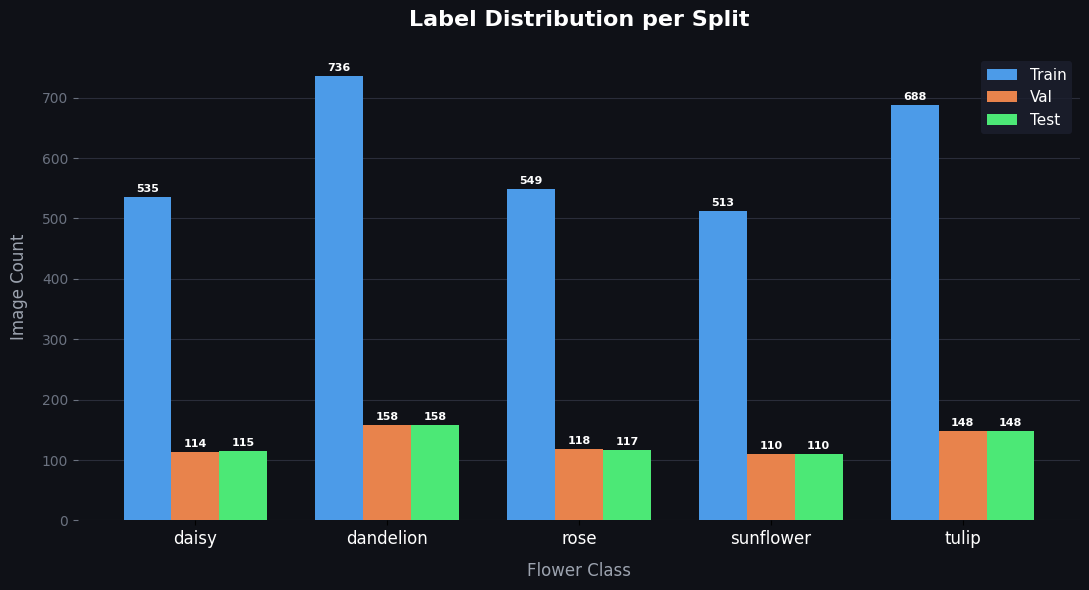

In [13]:
train_ds = make_dataset(X_train, y_train, augment=True)
val_ds   = make_dataset(X_val,   y_val,   augment=False)
test_ds  = make_dataset(X_test,  y_test,  augment=False)

class_names = encoder.classes_
x = np.arange(len(class_names))
width = 0.25

# Count each class in each split using the integer-encoded label arrays
splits = {
    "Train": y_train,
    "Val":   y_val,
    "Test":  y_test,
}
colors = ["#4C9BE8", "#E8834C", "#4CE876"]

fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor("#0F1117")
ax.set_facecolor("#0F1117")

for i, (split_name, y_split) in enumerate(splits.items()):
    counts = [np.sum(y_split == j) for j in range(len(class_names))]
    bars = ax.bar(x + (i - 1) * width, counts, width, label=split_name,
                  color=colors[i], edgecolor="none", zorder=3)
    for bar, count in zip(bars, counts):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 5,
            str(count),
            ha="center", va="bottom",
            color="white", fontsize=8, fontweight="bold"
        )

ax.yaxis.grid(True, color="#2A2D3A", linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_xticks(x)
ax.set_xticklabels(class_names, color="white", fontsize=12)
ax.tick_params(axis="y", colors="#6B7280", labelsize=10)
ax.set_title("Label Distribution per Split", color="white",
             fontsize=16, fontweight="bold", pad=20)
ax.set_xlabel("Flower Class", color="#9CA3AF", fontsize=12, labelpad=10)
ax.set_ylabel("Image Count",  color="#9CA3AF", fontsize=12, labelpad=10)
ax.legend(facecolor="#1C1F2E", edgecolor="none", labelcolor="white", fontsize=11)

plt.tight_layout()
plt.show()